In [7]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# 신경망 정의
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 1)
        )

    def forward(self, x):
        return self.net(x)

model = PINN()

# 학습용 x
x = torch.linspace(0, 1, 100).view(-1, 1)
x.requires_grad = True

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# 학습
for epoch in range(2000):
    u = model(x)

    du = torch.autograd.grad(
        u, x, torch.ones_like(u), create_graph=True
    )[0]

    d2u = torch.autograd.grad(
        du, x, torch.ones_like(du), create_graph=True
    )[0]

    loss = torch.mean((d2u + (np.pi**2) * torch.sin(np.pi * x))**2)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 200 == 0:
        print(epoch, loss.item())

0 50.21234893798828
200 0.0020273325499147177
400 0.0008482648408971727
600 0.00046052239486016333
800 0.00022662033734377474
1000 0.00012399142724461854
1200 9.209456038661301e-05
1400 8.219043957069516e-05
1600 7.553237082902342e-05
1800 0.00040627020644024014


In [8]:
# 경계조건 (x=0, x=1)
x_bc = torch.tensor([[0.0], [1.0]], requires_grad=True)
u_bc = torch.tensor([[0.0], [0.0]])  # sin(0)=0, sin(pi)=0

for epoch in range(2000):
    u = model(x)

    du = torch.autograd.grad(u, x, torch.ones_like(u), create_graph=True)[0]
    d2u = torch.autograd.grad(du, x, torch.ones_like(du), create_graph=True)[0]

    # PDE loss
    loss_pde = torch.mean((d2u + (np.pi**2) * torch.sin(np.pi * x))**2)

    # Boundary loss
    u_pred_bc = model(x_bc)
    loss_bc = torch.mean((u_pred_bc - u_bc)**2)

    # Total loss
    loss = loss_pde + loss_bc

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 200 == 0:
        print(epoch, loss.item())

0 1.5636401176452637
200 0.00032639718847349286
400 9.697510540718213e-05
600 6.993334682192653e-05
800 5.3044532251078635e-05
1000 3.9623904740437865e-05
1200 2.9419559723464772e-05
1400 2.2068439648137428e-05
1600 2.0436498743947595e-05
1800 0.0009069440420717001


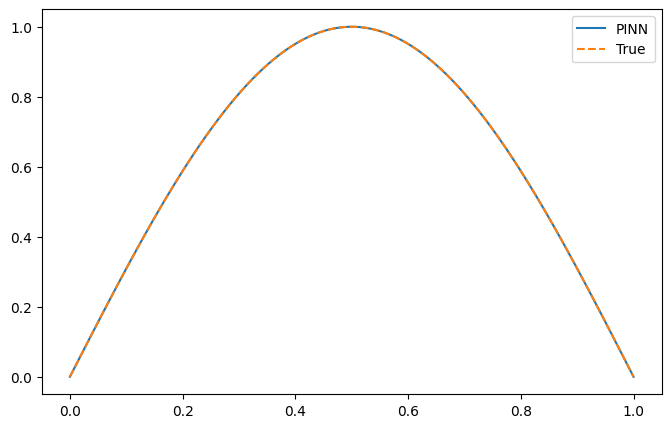

In [9]:
x_np = x.detach().numpy()
u_pred = model(x).detach().numpy()
u_true = np.sin(np.pi * x_np)

plt.figure(figsize=(8,5))
plt.plot(x_np, u_pred, label="PINN")
plt.plot(x_np, u_true, '--', label="True")
plt.legend()
plt.show()